## Task 1: Probability calibration on a toy dataset

#### Goal: Implement temperature scaling calibration for a neural network classifier on a synthetic dataset.

1. Generate a classification toy dataset using `make_classification` (5000 samples, 20 features). Convert to `float32` tensors and split into train/val, calibration, and test subsets.
2. Train a neural network classifier using cross-validation (5 folds). Save the best model checkpoint per fold — this produces an ensemble of 5 models.
3. Implement a `TemperatureScaler` module that wraps a trained model and divides its logits by a learnable scalar parameter `T`. Implement `fit_temperature` that optimizes `T` using `LBFGS` and `CrossEntropyLoss` on the calibration set. Fit a separate scaler for each of the 5 ensemble models.
4. Compute and plot calibration curves (fraction of positives vs. mean predicted probability, 10 bins) for each model before and after temperature scaling using `calibration_curve` from scikit-learn.
5. Compute Brier score before and after calibration using `brier_score_loss` for each ensemble model.

**Assignment:** Calibrate a classifier on the toy dataset using temperature scaling. Present results as calibration curves and Brier score values.


In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import torch
from utils import *

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [16]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=5000, n_features=20)
X, y = torch.tensor(X, dtype=torch.float), torch.tensor(y)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2)

In [17]:
model = MLP(input_size=20, hidden_layers=[64, 256, 64], output_size=2)

In [18]:
fold_models = []

fold_models = fold_train(X_trainval=X_trainval, y_trainval=y_trainval,
                         model=model, EPOCHS=2, device=device)

Fold 1/5 — best val loss: 0.6010
Fold 2/5 — best val loss: 0.5960
Fold 3/5 — best val loss: 0.6016
Fold 4/5 — best val loss: 0.5924
Fold 5/5 — best val loss: 0.5989


In [19]:
ensemble = [load_model(k, model, device) for k in fold_models]

scalers = []
for i, m in enumerate(ensemble):
    print(f"Fitting scaler for model {i+1}/5...")
    s = fit_temperature(m, X_test, y_test)
    scalers.append(s)

Fitting scaler for model 1/5...
  Fitted T = 2.2164
Fitting scaler for model 2/5...
  Fitted T = 2.2107
Fitting scaler for model 3/5...
  Fitted T = 2.2235
Fitting scaler for model 4/5...
  Fitted T = 2.2263
Fitting scaler for model 5/5...
  Fitted T = 2.2221


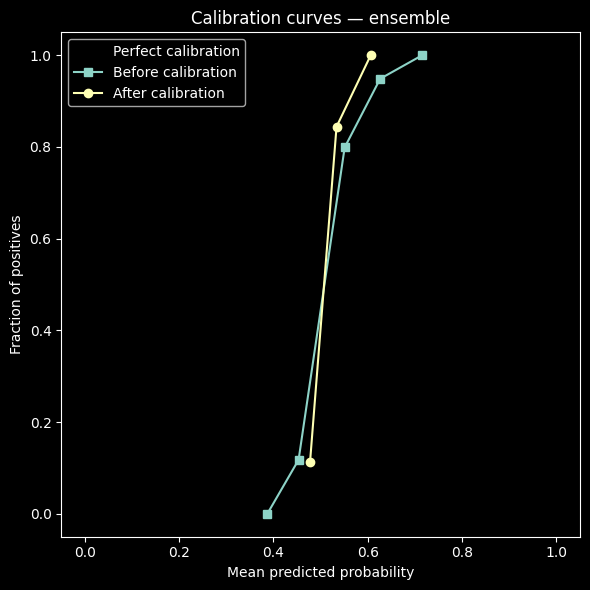

Brier score before: 0.2018
Brier score after: 0.2266


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

y_true = y_test.numpy()

probs_before = np.mean([get_probs(m, X_test, device) for m in ensemble], axis=0)
probs_after = np.mean([get_probs(s, X_test, device) for s in scalers],  axis=0)

frac_pos_before, mean_pred_before = calibration_curve(y_true, probs_before, n_bins=10)
frac_pos_after, mean_pred_after = calibration_curve(y_true, probs_after,  n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_pred_before, frac_pos_before, 's-', label='Before calibration')
ax.plot(mean_pred_after,  frac_pos_after,  'o-', label='After calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curves — ensemble')
ax.legend()
plt.tight_layout()
plt.show()

brier_before = brier_score_loss(y_true, probs_before)
brier_after = brier_score_loss(y_true, probs_after)
print(f"Brier score before: {brier_before:.4f}")
print(f"Brier score after: {brier_after:.4f}")